# 機械学習演習 第6回 問題4 解答

問題4「単回帰（年齢と血圧の関係）」の解答である。

このNotebookでは、`blood_pressure.csv`を読み込み、年齢と血圧の関係を散布図で確認し、外れ値を取り除いたうえで`LinearRegression`による単回帰式、決定係数$R^2$、係数$a$の95%信頼区間を求める。

## 事前準備

必要なライブラリを読み込む。ブートストラップの結果を再現できるように乱数シードを固定する。

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize-matplotlib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

SEED = 42

SyntaxError: invalid syntax (3923345326.py, line 4)

## 1. データファイルの準備

問題文ではデータファイル`blood_pressure.csv`をダウンロードするように指定されている。このNotebookでは、同じディレクトリに置かれている`blood_pressure.csv`を用いる。

In [ ]:
csv_path = "blood_pressure.csv"

## 2. `read_csv()`による読み込みとデータ確認

`pandas.read_csv()`でCSVファイルを読み込み、データの形状と最初の5行を確認する。

In [ ]:
df = pd.read_csv(csv_path)

print("shape:", df.shape)
display(df.head())

shape: (30, 2)


,age,blood pressure
0,39,144
1,47,220
2,45,138
3,47,145
4,65,162


In [ ]:
df.describe()

,age,blood pressure
count,30.000000,30.000000
mean,45.133333,142.533333
std,15.294203,22.581245
min,17.000000,110.000000
25%,36.750000,125.750000
50%,45.500000,141.000000
75%,56.000000,157.000000
max,69.000000,220.000000


**解説**

データは30行2列であり、列は`age`と`blood pressure`である。`age`が説明変数、`blood pressure`が目的変数である。

`describe()`により、各列の平均、標準偏差、最小値、四分位数、最大値を確認できる。血圧の最大値が220であり、他の値と比べて大きいことが分かる。

## 3. データのプロットと外れ値・相関の概観

年齢を横軸、血圧を縦軸として散布図を描く。これにより、外れ値の有無と相関の傾向を視覚的に確認する。

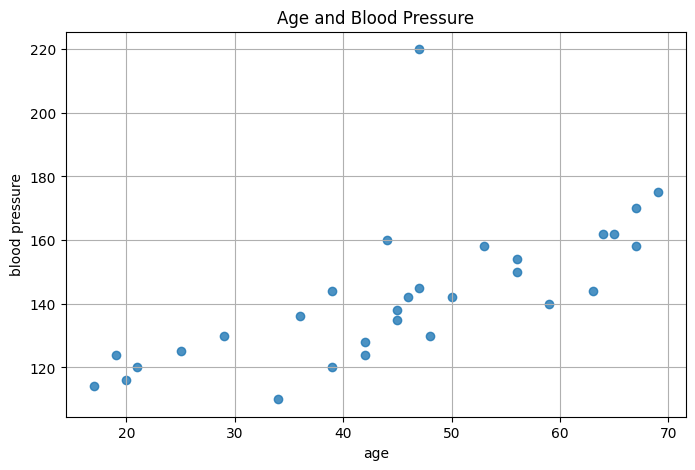

In [ ]:
plt.scatter(df["age"], df["blood pressure"], alpha=0.8)
plt.xlabel("age")
plt.ylabel("blood pressure")
plt.title("Age and Blood Pressure")
plt.show()

**解説**

散布図を見ると、年齢が高くなるほど血圧も高くなる傾向がある。一方で、`age = 47`、`blood pressure = 220`の点は周囲の点から大きく離れている。

この点は回帰直線に強く影響する可能性があるため、外れ値候補として扱う。

## 4. 外れ値の除去と単回帰式・決定係数$R^2$

外れ値の判定にはIQR法を用いる。第1四分位数を$Q_1$、第3四分位数を$Q_3$、四分位範囲を$IQR = Q_3 - Q_1$としたとき、

$$Q_1 - 1.5IQR$$

より小さい値、または

$$Q_3 + 1.5IQR$$

より大きい値を外れ値とみなす。

In [ ]:
numeric_cols = ["age", "blood pressure"]

q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).any(axis=1)
outliers = df[outlier_mask]
df2 = df[~outlier_mask].reset_index(drop=True)

print("lower bounds")
display(lower)
print("upper bounds")
display(upper)
print("outliers")
display(outliers)
print("df2.shape:", df2.shape)

lower bounds


age                7.875
blood pressure    78.875
dtype: float64

upper bounds


age                84.875
blood pressure    203.875
dtype: float64

outliers


,age,blood pressure
1,47,220


df2.shape: (29, 2)


**解説**

IQR法により、`age = 47`、`blood pressure = 220`の1点が外れ値として検出される。この点を除いたデータセットを`df2`とする。

このNotebookのデータでは、外れ値除去後のデータ数は29である。

In [ ]:
X = df2[["age"]]
y = df2["blood pressure"]

model = LinearRegression()
model.fit(X, y)

a_hat = model.coef_[0]
b_hat = model.intercept_
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"推定された単回帰式: blood pressure = {a_hat:.6f} age + {b_hat:.6f}")
print(f"決定係数 R^2: {r2:.6f}")

推定された単回帰式: blood pressure = 0.949323 age + 97.077084
決定係数 R^2: 0.712179


**解説**

外れ値を除いたデータに対して単回帰を行うと、このNotebookではおおよそ

$$\widehat{\mathrm{blood\ pressure}} = 0.949323 \times \mathrm{age} + 97.077084$$

となる。決定係数は$R^2 \simeq 0.712179$である。

傾きが正であるため、年齢が1歳増えると血圧は平均的に約0.95上昇するという関係が推定される。

外れ値を含めた場合の回帰結果も参考として確認する。外れ値が回帰式と決定係数に与える影響を見るためである。

In [ ]:
X_all = df[["age"]]
y_all = df["blood pressure"]

model_all = LinearRegression()
model_all.fit(X_all, y_all)
r2_all = r2_score(y_all, model_all.predict(X_all))

print(f"外れ値を含めた単回帰式: blood pressure = {model_all.coef_[0]:.6f} age + {model_all.intercept_:.6f}")
print(f"外れ値を含めた R^2: {r2_all:.6f}")

外れ値を含めた単回帰式: blood pressure = 0.970870 age + 98.714718
外れ値を含めた R^2: 0.432395


**補足**

外れ値を含めた場合、このNotebookでは$R^2 \simeq 0.432395$となる。外れ値を除いた場合の$R^2 \simeq 0.712179$より低くなるため、`blood pressure = 220`の点が直線関係の評価に大きく影響していることが分かる。

## 5. 回帰直線のプロット

外れ値を除いたデータと、求めた回帰直線を同じ図に描く。参考として、取り除いた外れ値も別の色で表示する。

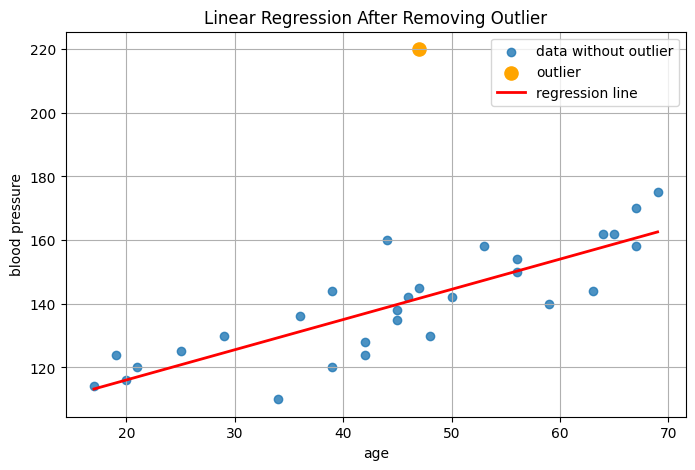

In [ ]:
x_grid = np.linspace(df["age"].min(), df["age"].max(), 200).reshape(-1, 1)
y_grid = model.predict(pd.DataFrame(x_grid, columns=["age"]))

plt.scatter(df2["age"], df2["blood pressure"], alpha=0.8, label="data without outlier")
plt.scatter(outliers["age"], outliers["blood pressure"], color="orange", s=90, label="outlier")
plt.plot(x_grid.ravel(), y_grid, color="red", linewidth=2, label="regression line")
plt.xlabel("age")
plt.ylabel("blood pressure")
plt.title("Linear Regression After Removing Outlier")
plt.legend()
plt.show()

**解説**

赤い直線が、外れ値を除いたデータに対して求めた単回帰直線である。散布図からも、年齢と血圧には正の相関があることが確認できる。

外れ値を取り除くことで、多くのデータ点の傾向に沿った回帰直線になっている。

## 6. ブートストラップ法による係数$a$の95%信頼区間

外れ値を除いたデータ`df2`から、重複を許して同じデータ数だけリサンプリングする。各リサンプルに対して単回帰を行い、係数$a$を2000回求める。

得られた係数$a$の2.5パーセンタイルと97.5パーセンタイルを、95%信頼区間とする。

In [ ]:
n_bootstrap = 2000
rng = np.random.default_rng(SEED)

X_np = X.to_numpy()
y_np = y.to_numpy()
n = len(df2)

a_bootstrap = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    sample_idx = rng.integers(0, n, size=n)
    X_sample = X_np[sample_idx]
    y_sample = y_np[sample_idx]

    boot_model = LinearRegression()
    boot_model.fit(X_sample, y_sample)
    a_bootstrap[i] = boot_model.coef_[0]

ci_lower, ci_upper = np.percentile(a_bootstrap, [2.5, 97.5])

print(f"元データから推定した a: {a_hat:.6f}")
print(f"ブートストラップ平均: {a_bootstrap.mean():.6f}")
print(f"95%信頼区間: [{ci_lower:.6f}, {ci_upper:.6f}]")

元データから推定した a: 0.949323
ブートストラップ平均: 0.955603
95%信頼区間: [0.766128, 1.168639]


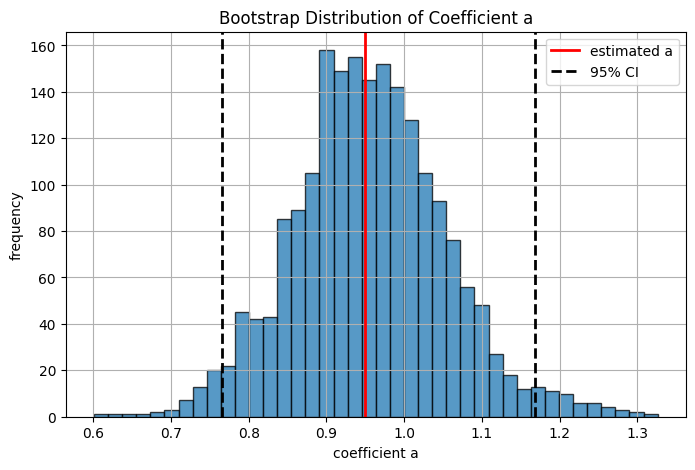

In [ ]:
plt.hist(a_bootstrap, bins=40, alpha=0.75, edgecolor="black")
plt.axvline(a_hat, color="red", linewidth=2, label="estimated a")
plt.axvline(ci_lower, color="black", linestyle="--", linewidth=2, label="95% CI")
plt.axvline(ci_upper, color="black", linestyle="--", linewidth=2)
plt.xlabel("coefficient a")
plt.ylabel("frequency")
plt.title("Bootstrap Distribution of Coefficient a")
plt.legend()
plt.show()

**解説**

このNotebookの固定シードでは、係数$a$の95%信頼区間はおおよそ

$$[0.766128, 1.168639]$$

となる。

信頼区間が0を含まないため、年齢と血圧の間には正の関係があると考えられる。ただし、これはこの標本に基づく推定であり、データ数が29と少ない点には注意が必要である。

## まとめ

- `blood_pressure.csv`を読み込み、データが30行2列であることを確認した。
- 散布図から、年齢と血圧には正の相関があり、`age = 47`、`blood pressure = 220`の点が外れ値候補であることを確認した。
- IQR法により、`blood pressure = 220`の1点を外れ値として除外した。
- 外れ値除去後の単回帰式は、おおよそ$\widehat{\mathrm{blood\ pressure}} = 0.949323 \times \mathrm{age} + 97.077084$となった。
- 外れ値除去後の決定係数は$R^2 \simeq 0.712179$であった。
- ブートストラップ法を2000回行い、係数$a$の95%信頼区間をおおよそ$[0.766128, 1.168639]$と求めた。